In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('cust_satisfaction.csv')

In [3]:
df.drop_duplicates(inplace=True)

In [4]:
df.dropna(inplace=True)

In [5]:
print("total null values",df.isnull().sum())
print("total duplicate values",df.duplicated().sum())

total null values Gender                        0
Customer Type                 0
Type of Travel                0
Class                         0
satisfaction                  0
Age                           0
Flight Distance               0
Inflight entertainment        0
Baggage handling              0
Cleanliness                   0
Departure Delay in Minutes    0
Arrival Delay in Minutes      0
dtype: int64
total duplicate values 0


In [6]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Business travel':1, 'Personal Travel':0})
df['Class'] = df['Class'].map({'Business':2, 'Eco Plus':1, 'Eco':0})
df['satisfaction'] = df['satisfaction'].map({'satisfied':1, 'neutral or dissatisfied':0})

In [7]:
df

,Gender,Customer Type,Type of Travel,Class,satisfaction,Age,Flight Distance,Inflight entertainment,Baggage handling,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,1,0,1,0,13,460,5,4,5,25,18.0
1,1,0,1,2,0,25,235,1,3,1,1,6.0
2,0,1,1,2,1,26,1142,5,4,5,0,0.0
3,0,1,1,2,0,25,562,2,3,2,11,9.0
4,1,1,1,2,1,61,214,3,4,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
103899,0,0,1,0,0,23,192,2,4,2,3,0.0
103900,1,1,1,2,1,49,2347,5,5,4,0,0.0
103901,1,0,1,2,0,30,1995,4,4,4,7,14.0
103902,0,0,1,0,0,22,1000,1,1,1,0,0.0


In [8]:
print("Total Index:",df['Customer Type'].value_counts().index)

Total Index: Index([1, 0], dtype='int64', name='Customer Type')


In [9]:
print("total values:",df['Customer Type'].value_counts().values)

total values: [84517 18905]


In [10]:
df['Customer Type'].value_counts().keys

<bound method Series.keys of Customer Type
1    84517
0    18905
Name: count, dtype: int64>

In [11]:
print("Indexing Value:-",df['Customer Type'].value_counts().index)

Indexing Value:- Index([1, 0], dtype='int64', name='Customer Type')


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\harsh\AppData\Local\Temp\ipykernel_14448\2787587337.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=label, y=index, kind='bar', palette=color)


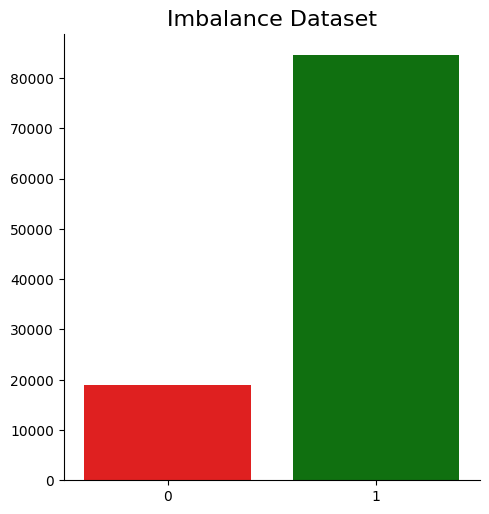

In [13]:
index = list((df['Customer Type'].value_counts().values))
label = list((df['Customer Type'].value_counts().keys()))
color= ['red', 'green']
sns.catplot(x=label, y=index, kind='bar', palette=color)
plt.title("Imbalance Dataset", fontsize=16)
plt.show()

In [14]:
loyal_customer = df[df['Customer Type']==1].loc[0:20000]
disloyal_customer = df[df['Customer Type']==0]

C:\Users\harsh\AppData\Local\Temp\ipykernel_14448\4045726825.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = list((balanced_df['Customer Type'].value_counts().keys())),


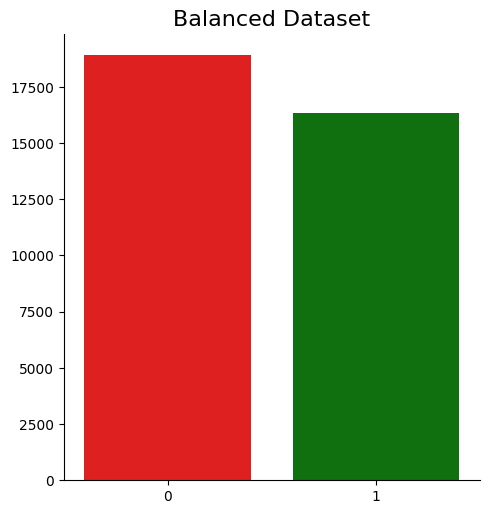

In [15]:
balanced_df = pd.concat([loyal_customer, disloyal_customer])
colors = ['red', 'green']
sns.catplot(x = list((balanced_df['Customer Type'].value_counts().keys())),
y = list((balanced_df['Customer Type'].value_counts().values)),kind='bar', palette=colors)
plt.title("Balanced Dataset", fontsize=16) 
plt.show()

In [16]:
balanced_df.isnull().sum()

Gender                        0
Customer Type                 0
Type of Travel                0
Class                         0
satisfaction                  0
Age                           0
Flight Distance               0
Inflight entertainment        0
Baggage handling              0
Cleanliness                   0
Departure Delay in Minutes    0
Arrival Delay in Minutes      0
dtype: int64

In [31]:
#splitting data into dependent and independent features
x = balanced_df.drop('Customer Type', axis=1)  
y = balanced_df['Customer Type']

In [18]:
print(x.shape)
print(y.shape)

(35239, 11)
(35239,)


In [19]:
#split in train and test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(28191, 11)
(7048, 11)
(28191,)
(7048,)


In [20]:
from sklearn.preprocessing import StandardScaler
st_scaler = StandardScaler()
x_train = st_scaler.fit_transform(x_train)
x_test = st_scaler.transform(x_test)

In [21]:
import tensorflow as tf

In [22]:
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential, load_model
### Defining ANN Model

Ann_Model = Sequential()
# Hidden layers
Ann_Model.add(Dense(units=68,activation='relu',input_dim=x_train.shape[1]))
Ann_Model.add(Dense(units=32,activation='relu'))
Ann_Model.add(Dense(units=24,activation='relu'))
Ann_Model.add(Dense(units=12,activation='relu'))
#output layers
Ann_Model.add(Dense(units=1,activation='sigmoid'))

#compiling the models
Ann_Model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
Ann_Model.summary()

c:\Users\harsh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 68)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,129 (16.13 KB)

 Trainable params: 4,129 (16.13 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = Ann_Model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=64)

Epoch 1/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8765 - loss: 0.3082 - val_accuracy: 0.8997 - val_loss: 0.2565
Epoch 2/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9067 - loss: 0.2387 - val_accuracy: 0.9099 - val_loss: 0.2342
Epoch 3/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9121 - loss: 0.2276 - val_accuracy: 0.9132 - val_loss: 0.2243
Epoch 4/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9149 - loss: 0.2187 - val_accuracy: 0.9123 - val_loss: 0.2263
Epoch 5/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9175 - loss: 0.2118 - val_accuracy: 0.9183 - val_loss: 0.2160
Epoch 6/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9210 - loss: 0.2073 - val_accuracy: 0.9167 - val_loss: 0.2133
Epoch 7/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9228 - loss: 0.2026 - val_accuracy: 0.9176 - val_loss: 0.2103
Epoch 8/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9234 - loss: 0.1994 - val_accu

In [24]:
import pandas as pd
training_details = pd.DataFrame(history.history)
training_details

,accuracy,loss,val_accuracy,val_loss
0,0.876521,0.308210,0.899688,0.256519
1,0.906743,0.238662,0.909904,0.234160
2,0.912064,0.227644,0.913167,0.224332
3,0.914866,0.218714,0.912316,0.226318
4,0.917491,0.211794,0.918275,0.216014
...,...,...,...,...
95,0.944911,0.142758,0.923950,0.217771
96,0.946614,0.140198,0.920687,0.221096
97,0.945692,0.140004,0.924092,0.228723
98,0.945337,0.141426,0.924943,0.213846


<Axes: >

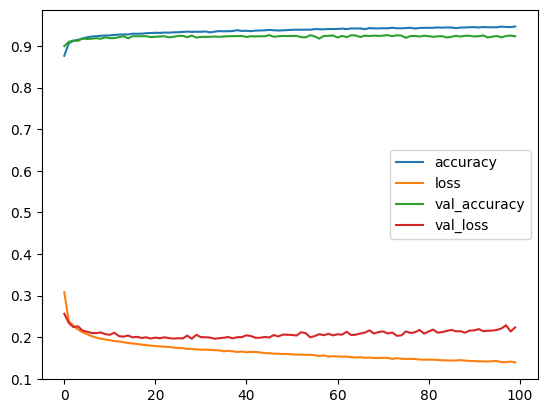

In [25]:
training_details.plot()

<Axes: >

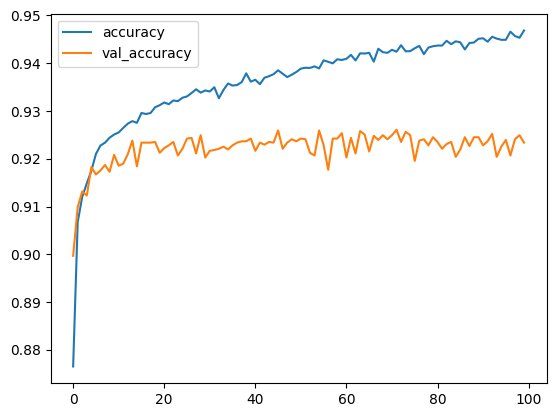

In [26]:
training_details[['accuracy', 'val_accuracy']].plot() #training accuracy vs validation accuracy

In [27]:
#get prediction probability
y_pred = Ann_Model.predict(x_test)
prediction_label = (y_pred > 0.5).astype("int").ravel()
prediction_label

221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([1, 0, 0, ..., 1, 0, 1], shape=(7048,))

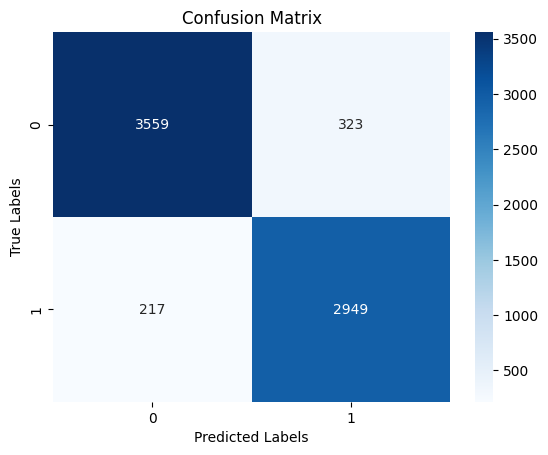

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

cm = confusion_matrix(prediction_label, y_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [29]:
print(classification_report(prediction_label, y_test))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3882
           1       0.90      0.93      0.92      3166

    accuracy                           0.92      7048
   macro avg       0.92      0.92      0.92      7048
weighted avg       0.92      0.92      0.92      7048



In [30]:
Ann_Model.save('customer_satisfaction_model.h5') #save the model

#load the model
Ann_Model = load_model('customer_satisfaction_model.h5')

